<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/binary_CE%5B1%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q imbalanced-learn scikeras seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import BinaryCrossentropy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


In [5]:
X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values

In [6]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [7]:
y_res_cat  = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [8]:
def ecg_to_image(ecg_batch):

    ecg_batch = ecg_batch.reshape(-1,187,1)
    ecg_batch = np.expand_dims(ecg_batch, axis=-1)

    ecg_batch = tf.image.resize(ecg_batch,(224,224))
    ecg_batch = tf.image.grayscale_to_rgb(ecg_batch)

    return ecg_batch

In [9]:
BATCH_SIZE = 32

def data_generator(X, y, batch_size):

    while True:
        for i in range(0, len(X), batch_size):

            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            X_batch_img = ecg_to_image(X_batch)

            yield X_batch_img, y_batch

In [10]:
train_gen = data_generator(X_res, y_res_cat, BATCH_SIZE)
test_gen  = data_generator(X_test, y_test_cat, BATCH_SIZE)

In [11]:
loss_fn = BinaryCrossentropy()

In [12]:
def mobilenet_model():

    base_model = MobileNet(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    outputs = Dense(5, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer="adam",
        loss=loss_fn,
        metrics=["accuracy"]
    )

    return model

model = mobilenet_model()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
history = model.fit(
    train_gen,
    steps_per_epoch=len(X_res)//BATCH_SIZE,
    validation_data=test_gen,
    validation_steps=len(X_test)//BATCH_SIZE,
    epochs=20
)

Epoch 1/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 393s 33ms/step - accuracy: 0.9913 - loss: 0.0345 - val_accuracy: 0.0733 - val_loss: 6.8163
Epoch 2/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 379s 33ms/step - accuracy: 0.9842 - loss: 0.0628 - val_accuracy: 0.0718 - val_loss: 5.9903
Epoch 3/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 368s 32ms/step - accuracy: 0.9861 - loss: 0.0502 - val_accuracy: 0.0704 - val_loss: 5.6571
Epoch 4/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 374s 33ms/step - accuracy: 0.9868 - loss: 0.0450 - val_accuracy: 0.0692 - val_loss: 5.3790
Epoch 5/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 362s 32ms/step - accuracy: 0.9875 - loss: 0.0413 - val_accuracy: 0.0692 - val_loss: 5.1487
Epoch 6/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 362s 32ms/step - accuracy: 0.9879 - loss: 0.0385 - val_accuracy: 0.0692 - val_loss: 4.9779
Epoch 7/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 363s 32ms/step - accuracy: 0.9884 - loss: 0.0364 - val_accuracy: 0.0692 - val_loss: 4.8519
Epoch 8/20
11323/11323 ━━━━━━━━━━━━━━━━━━━━ 362s 32ms/s

In [14]:
loss, accuracy = model.evaluate(
    test_gen,
    steps=len(X_test)//BATCH_SIZE
)

print("Test Accuracy:", accuracy)

684/684 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.1199 - loss: 4.1914
Test Accuracy: 0.08266239613294601


In [15]:
predictions = model.predict(
    test_gen,
    steps=len(X_test)//BATCH_SIZE
)

y_pred = np.argmax(predictions, axis=1)
y_true = y_test[:len(y_pred)]

684/684 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step


In [16]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     18118
         1.0       0.06      0.01      0.02       556
         2.0       0.60      0.03      0.05      1448
         3.0       0.01      0.03      0.01       162
         4.0       0.07      0.92      0.13      1576

    accuracy                           0.07     21860
   macro avg       0.15      0.20      0.04     21860
weighted avg       0.05      0.07      0.01     21860



In [17]:
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Overall Weighted Precision:", precision)
print("Overall Weighted Recall:", recall)
print("Overall Weighted F1 Score:", f1)

Overall Weighted Precision: 0.04625890278081955
Overall Weighted Recall: 0.06843549862763038
Overall Weighted F1 Score: 0.013079613629933413


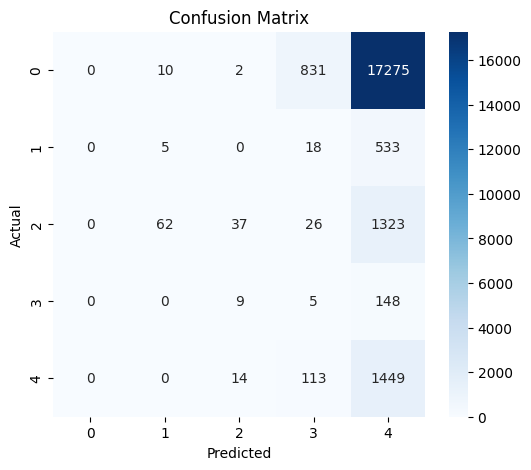

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
model.save("/content/drive/MyDrive/ecg_mobilenet_model.h5")

In [1]:
train_loss, train_accuracy = model.evaluate(
    train_gen,
    steps=len(X_res)//BATCH_SIZE
)

print("Train Accuracy:", train_accuracy)

NameError: name 'model' is not defined